# [LandShift] Landscape

---
<div>For the Landscape analysis, this notebook is adapted from the PyLM algorithm described in [Giuliani - 2026](https://doi.org/10.3390/land15010187)</div>
<div>More details on the methodology are available in Deliverable D3.5 </div>

<br><i>Author(s):</i> <a href='https://www.unige.ch/envirospace/people/giuliani' target='_blank'>Gregory Giuliani</a>
<br><i>Version:</i> 1.0
<br><i>Date:</i> 2026-04-21
<br><i>Supported by:</i> Horizon-Europe <a href='https://landshift.eu' target='_blank'>LandShift</a> project

---
<a id="initialize"></a>
## Initialization
<div style="text-align: justify">This module first test if the necessary librairies are installed and then user is able to define both input and output folders.</div>

### Load librairies

In [1]:
# Test if the libraries are installed and if not install them
import os

try:
  import numpy
except:
  !pip install numpy
  import numpy

try:
  import rasterio
except:
  !pip install rasterio
  import rasterio

try:
  import scipy
except:
  !pip install scipy
  import scipy

try:
  import csv
except:
  !pip install csv
  import csv

try: 
    import matplotlib
except:
    os.system('pip install matplotlib')
    import matplotlib

#Import all necessary libraries
import numpy as np
import rasterio.mask
from matplotlib import pyplot
import matplotlib.pyplot as plt
from rasterio.plot import show
from itertools import product
from rasterio.transform import Affine
from rasterio.transform import from_origin
from numpy.lib.stride_tricks import sliding_window_view

### Define the input and output folders

In [2]:
lccsFile = '/Users/gregorygiuliani/Desktop/ecosystem/input/LE_D26_basilicata_2020_data.tif' #To be adapted by user
outputFolder = '/Users/gregorygiuliani/Desktop/ecosystem/output/' #To be adapted by user

name = os.path.basename(lccsFile)
print(name)

LE_D26_basilicata_2020_data.tif


<a id="inputdata"></a>
## Input Data
<div style="text-align: justify">The input image for the Landscape Mosaic analysis must be a raster map with no more than 3 target classes having the assignment AND (1 Byte - Agriculture, 2 Byte - Natural, 3 Byte - Developed) plus an optional class value of 0 Byte which is reserved for masking missing/no-data pixels. The target classes must not necessary be Agriculture, Natural, Developed but could be any three prevalent land cover types in a given area.</div>

In [3]:
#read the 3-classes geotiff file
l3 = rasterio.open(lccsFile)

### Layer information

In [4]:
#Print different information on the layer
#Dimensions
print('Width: '+str(l3.width))
print('Height: '+str(l3.height))

#CRS
print('CRS: '+str(l3.crs))

# Bounds of the file
print('BBOXh: '+str(l3.bounds))

#Number of band
print('Index: '+str(l3.indexes))

#Resolution
print('Resolution: '+str(l3.res))

#Bands
band_names = l3.descriptions
print('Bands: '+str(band_names))

#Get unique LCCS3 code present in the map
band1 = l3.read(1)
np.unique(band1)

Width: 13427
Height: 14138
CRS: EPSG:6875
BBOXh: BoundingBox(left=7279600.0, bottom=4417380.0, right=7413870.0, top=4558760.0)
Index: (1, 2, 3, 4, 5, 6, 7, 8)
Resolution: (10.0, 10.0)
Bands: (None, None, None, None, None, None, None, None)


array([  0, 111, 112, 123, 124, 215, 216, 220], dtype=uint8)

### Layer visualization

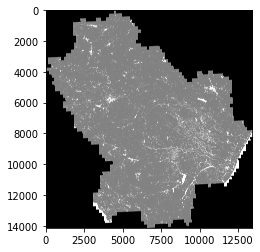

In [5]:
#Visualize the LCCS Level-3 map
pyplot.imshow(band1, cmap='grey')
pyplot.show()  

### Map conversion [optional]
To comply with the LM-input requirements, this input image is then re-mapped into the 3 land cover types: Agriculture (1), Natural(2), Developed(3).
<br>IMPORTANT: this module should be adapted to your LC classification schema (hereafter we provide an example based on the ESA CCI schema)

|Value|LCCS Code|LCCS Description|LM Code|LM Description|
|---|---|---|---|---|
|111|A11|Cultivated Terrestrial Vegetated|1|Agriculture|
|112|A12|Natural Terrestrial Vegetated|2|Natural|
|123|A23|Cultivated Aquatic Vegetated|1|Agriculture|
|124|A24|Natural Aquatic Vegetated|2|Natural|
|215|B15|Artificial Surface|3|Developed|
|216|B16|Bare Surface|2|Natural|
|220|B27|Water|2|Natural|

In [6]:

# Open the source raster
with rasterio.open(lccsFile) as src:
    band1 = src.read(1)
    meta = src.meta.copy()
    meta.update({
        "count": 1,
        "dtype": src.dtypes[0]
    })

with rasterio.open(outputFolder + "output_band1.tif", "w", **meta) as dst:
    dst.write(band1, 1)
print("Band 1 extracted successfully!")

# Reclassify
with rasterio.open(outputFolder + "output_band1.tif") as src:
    array = src.read(1)
    profile = src.profile

array[np.where(array == 0)]   = 0
array[np.where(array == 111)] = 1
array[np.where(array == 112)] = 2
array[np.where(array == 123)] = 1
array[np.where(array == 124)] = 2
array[np.where(array == 215)] = 3
array[np.where(array == 216)] = 2
array[np.where(array == 220)] = 2

with rasterio.open(outputFolder + 'l3_reclass.tif', 'w', **profile) as dst:
    dst.write(array, 1)  # ← add the band index here
print(f"Reclassified file '{outputFolder + 'l3_reclass.tif'}' created successfully.")

Band 1 extracted successfully!
Reclassified file '/Users/gregorygiuliani/Desktop/ecosystem/output/l3_reclass.tif' created successfully.


<a id="lmAnalysis"></a>
## LM Analysis
<i>from <a href='https://ies-ows.jrc.ec.europa.eu/gtb/GTB/psheets/GTB-Pattern-LM.pdf' target='_blank'>Vogt et al. (2024)</a> and <a href='https://publications.jrc.ec.europa.eu/repository/handle/JRC120383' target='_blank'>Maes et al. (2020)</a></i>
<div style="text-align: justify">Each pixel in the LM-image is derived by a moving window procedure in the following way: a) a fixed-area square window is centered over a given pixel of the land cover type image; b) the composition of the three land cover types (the contribution triplet in A, N, D) is calculated from the pixels covered by the square window; c) the corresponding mosaic class is placed on the LM-image at the location of the investigated pixel. This implies that each pixel in the LM-image describes the land cover context within the surrounding square area.</div>
<div style="text-align: justify">The full LM-information is then summarised into the following five stratification layers with specific focus on dedicated thematic topics: 

1. LM-Background: LM summary into 4 classes: Natural, Agriculture, Developed and Mixed.  

2. LM-Diversity: LM summary into 4 classes showing increasing degree of land cover diversity from Uniform, Dual, Triple, to Intermixed land cover.  

3. LM-Agriculture: LM interface summary into 3 classes showing areas where agricultural land cover is dominant (>= 60%), subdominant, or minor (<10%).  

4. LM-Natural: LM interface summary into 3 classes showing areas where natural land cover is dominant (>= 60%), subdominant, or minor (<10%).  

5. LM-Developed: LM interface summary into 3 classes showing areas where developed land cover is dominant (>= 60%), subdominant, or minor (<10%).

<div>
<div style="text-align: justify">The scope of the LM-Background layer is to facilitate the reporting on land cover composition by focusing on the dominant presence (>= 60%) of each of the three land cover types. The second stratification layer, LMDiversity, reports on the degree of spatial land cover heterogeneity. Because land cover dynamics are mainly driven by human activities it is of interest to investigate the interface zones for each of the 3 land cover types with their surrounding neighbourhood. Hence, the purpose of the stratification layer 4 (LM-Natural) is to delineate areas with prevalent natural land cover from those impacted by anthropogenic activities. The purpose of the stratification layers 3 (LM-Agriculture) and 5 (LM-Developed) is to locate and show the intensity of the human footprint on the landscape originating from Agriculture and Developed pressure, respectively. The mapping of the three interface zones (stratification layer 3-5) is an essential prerequisite for policy planning, monitoring and assessment, and towards understanding potential impacts of anthropogenic activities on the environment.</div>
    
<div style="text-align: justify">Because each pixel has a contribution triplet in A, N, D, it will fall in one of the 103 sub-spaces of the LM-triangle. The heatmap shows the relative occurrence frequency of all LM-image pixels. Because occurrence frequencies are shown in percent, the heatmap can be used to a) compare landscape composition for images of different extent, or b) investigate time series at the same observation scale, or c) investigate changes in land cover prevalence across different scales.</div>

### Moving Window count
Computes the frequencies for the three end-members and store them into a 3D-array

In [7]:
# Open and read the 3-class (Agriculture, Natural, Developed) raster
src = rasterio.open(outputFolder+'l3_reclass.tif')
raster = src.read(1)

In [8]:
#General idea: iterate over the entire array
#for each pixel > store c1-c2-c3 (values store in a 3-band raster, each representing one class
#the produced raster is then used for the Map - Heatmap - LM_Background, ...

#window size
res=10

# Define the window shape
window_shape = (res, res)

# Padding size to ensure all pixels are included
pad_width = res // 2

# Pad the input 2D array to ensure that all pixels of the country are processed
padded_raster = np.pad(raster, pad_width, mode='edge')

# Create a sliding window view of the raster with shape
windows = np.lib.stride_tricks.sliding_window_view(padded_raster, window_shape)

# Initialize an array to store the result
result = np.empty((3, windows.shape[0], windows.shape[1]), dtype=np.uint16)

# Iterate over the windows
for i in range(windows.shape[0]):
    for j in range(windows.shape[1]):

        # Extract the current 10x10 window
        window = windows[i, j]

        # Calculate the sum and store it in the result array
        result[0, i, j] = np.count_nonzero(window == 1)  # Band 1: Agriculture count
        result[1, i, j] = np.count_nonzero(window == 2)   # Band 2: Natural count
        result[2, i, j] = np.count_nonzero(window == 3)   # Band 3: Developed count

# Save the result as a new GeoTIFF file
output_filename = outputFolder+"lmCount.tif"

# Define GeoTIFF metadata, you may need to adjust these depending on your data 
transform = from_origin(src.bounds.left, src.bounds.top, src.res[0], src.res[0])  # transform (origin x, origin y, pixel size x, pixel size y)
new_dtype = raster.dtype

with rasterio.open(
    output_filename,
    "w",
    driver="GTiff",
    height=result.shape[1],
    width=result.shape[2],
    count=3,  # Three bands for mean, min, and max
    dtype=new_dtype,
    crs=src.crs,  # Coordinate reference system
    transform=transform,
) as dst:
    dst.write(result[0], 1)  # Write Band 1 (agriculture)
    dst.write(result[1], 2)  # Write Band 2 (natural)
    dst.write(result[2], 3)  # Write Band 3 (developed)

print(f"GeoTIFF file '{output_filename}' created successfully.")

GeoTIFF file '/Users/gregorygiuliani/Desktop/ecosystem/output/lmCount.tif' created successfully.


### 103-classes
Computes the 103-classes defined by the LM model

In [9]:
# Read the 3-band raster and define the outputs
input_raster = outputFolder+"lmCount.tif"
output_raster = outputFolder+"lm103class.tif"

with rasterio.open(input_raster) as src:
    # Read the raster bands into a 3D numpy array (Bands, Rows, Columns)
    bands = src.read()
    profile = src.profile  # Save the profile for writing later

# Example shape: (3, Height, Width)
print("Raster shape:", bands.shape)

# Assign unique values to each condition or combination
reclassified = np.zeros_like(bands[0], dtype=np.uint8)  # Initialize with zeros

# Apply unique values based on the conditions
# !!! texture triangle:: band 0 + band 1 + band 2 == 100
reclassified[(bands[0] == 0) & (bands[1] == 0) & (bands[2] == 0)] = 0 #Missing
reclassified[(bands[0] >= 90) & (bands[0] <= 100) & (
              bands[1] >= 0) & (bands[1] <= 10) & (
              bands[2] >= 0) & (bands[2] <= 10)
              ] = 181
reclassified[(bands[0] >= 80) & (bands[0] < 90) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 41
reclassified[(bands[0] >= 80) & (bands[0] < 90) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 0) & (bands[2] <= 10)
              ] = 182
reclassified[(bands[0] >= 80) & (bands[0] < 90) & (
              bands[1] >= 10) & (bands[1] <= 20) & (
              bands[2] >= 0) & (bands[2] <= 10)
              ] = 51
reclassified[(bands[0] >= 70) & (bands[0] < 80) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 20) & (bands[2] <= 30)
              ] = 43
reclassified[(bands[0] >= 70) & (bands[0] < 80) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 42
reclassified[(bands[0] >= 70) & (bands[0] < 80) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 101
reclassified[(bands[0] >= 70) & (bands[0] < 80) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 0) & (bands[2] <= 10)
              ] = 52
reclassified[(bands[0] >= 70) & (bands[0] < 80) & (
              bands[1] >= 20) & (bands[1] <= 30) & (
              bands[2] >= 0) & (bands[2] <= 10)
              ] = 53
reclassified[(bands[0] >= 60) & (bands[0] < 70) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 30) & (bands[2] <= 40)
              ] = 45
reclassified[(bands[0] >= 60) & (bands[0] < 70) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 20) & (bands[2] <= 30)
              ] = 44
reclassified[(bands[0] >= 60) & (bands[0] < 70) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 20) & (bands[2] <= 30)
              ] = 103
reclassified[(bands[0] >= 60) & (bands[0] < 70) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 102
reclassified[(bands[0] >= 60) & (bands[0] < 70) & (
              bands[1] >= 20) & (bands[1] < 30) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 104
reclassified[(bands[0] >= 60) & (bands[0] < 70) & (
              bands[1] >= 20) & (bands[1] < 30) & (
              bands[2] > 0) & (bands[2] <= 10)
              ] = 54
reclassified[(bands[0] >= 60) & (bands[0] < 70) & (
              bands[1] >= 30) & (bands[1] <= 40) & (
              bands[2] >= 0) & (bands[2] <= 10)
              ] = 55
reclassified[(bands[0] >= 50) & (bands[0] < 60) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 40) & (bands[2] <= 50)
              ] = 134
reclassified[(bands[0] >= 50) & (bands[0] < 60) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 30) & (bands[2] <= 40)
              ] = 135
reclassified[(bands[0] >= 50) & (bands[0] < 60) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 30) & (bands[2] <= 40)
              ] = 205
reclassified[(bands[0] >= 50) & (bands[0] < 60) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 20) & (bands[2] <= 30)
              ] = 206
reclassified[(bands[0] >= 50) & (bands[0] < 60) & (
              bands[1] >= 20) & (bands[1] < 30) & (
              bands[2] > 20) & (bands[2] <= 30)
              ] = 207
reclassified[(bands[0] >= 50) & (bands[0] < 60) & (
              bands[1] >= 20) & (bands[1] < 30) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 208
reclassified[(bands[0] >= 50) & (bands[0] < 60) & (
              bands[1] >= 30) & (bands[1] < 40) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 209
reclassified[(bands[0] >= 50) & (bands[0] < 60) & (
              bands[1] >= 30) & (bands[1] < 40) & (
              bands[2] > 0) & (bands[2] <= 10)
              ] = 141
reclassified[(bands[0] >= 50) & (bands[0] < 60) & (
              bands[1] >= 40) & (bands[1] <= 50) & (
              bands[2] >= 0) & (bands[2] <= 10)
              ] = 142
reclassified[(bands[0] >= 40) & (bands[0] < 50) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 50) & (bands[2] <= 60)
              ] = 132
reclassified[(bands[0] >= 40) & (bands[0] < 50) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 40) & (bands[2] <= 50)
              ] = 133
reclassified[(bands[0] >= 40) & (bands[0] < 50) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 40) & (bands[2] <= 50)
              ] = 203
reclassified[(bands[0] >= 40) & (bands[0] < 50) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 30) & (bands[2] <= 40)
              ] = 204
reclassified[(bands[0] >= 40) & (bands[0] < 50) & (
              bands[1] >= 20) & (bands[1] < 30) & (
              bands[2] > 30) & (bands[2] <= 40)
              ] =  227
reclassified[(bands[0] >= 40) & (bands[0] < 50) & (
              bands[1] >= 20) & (bands[1] < 30) & (
              bands[2] > 20) & (bands[2] <= 30)
              ] = 228
reclassified[(bands[0] >= 40) & (bands[0] < 50) & (
              bands[1] >= 30) & (bands[1] < 40) & (
              bands[2] > 20) & (bands[2] <= 30)
              ] = 229
reclassified[(bands[0] >= 40) & (bands[0] < 50) & (
              bands[1] >= 30) & (bands[1] < 40) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 210
reclassified[(bands[0] >= 40) & (bands[0] < 50) & (
              bands[1] >= 40) & (bands[1] < 50) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 211
reclassified[(bands[0] >= 40) & (bands[0] < 50) & (
              bands[1] >= 40) & (bands[1] < 50) & (
              bands[2] > 0) & (bands[2] <= 10)
              ] = 143
reclassified[(bands[0] >= 40) & (bands[0] < 50) & (
              bands[1] >= 50) & (bands[1] <= 60) & (
              bands[2] >= 0) & (bands[2] <= 10)
              ] = 144
reclassified[(bands[0] >= 30) & (bands[0] < 40) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 60) & (bands[2] <= 70)
              ] = 75
reclassified[(bands[0] >= 30) & (bands[0] < 40) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 50) & (bands[2] <= 60)
              ] =  131
reclassified[(bands[0] >= 30) & (bands[0] < 40) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 50) & (bands[2] <= 60)
              ] = 201
reclassified[(bands[0] >= 30) & (bands[0] < 40) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 40) & (bands[2] <= 50)
              ] = 202
reclassified[(bands[0] >= 30) & (bands[0] < 40) & (
              bands[1] >= 20) & (bands[1] < 30) & (
              bands[2] > 40) & (bands[2] <= 50)
              ] = 225
reclassified[(bands[0] >= 30) & (bands[0] < 40) & (
              bands[1] >= 20) & (bands[1] < 30) & (
              bands[2] > 30) & (bands[2] <= 40)
              ] = 226
reclassified[(bands[0] >= 30) & (bands[0] < 40) & (
              bands[1] >= 30) & (bands[1] < 40) & (
              bands[2] > 30) & (bands[2] <= 40)
              ] = 236
reclassified[(bands[0] >= 30) & (bands[0] < 40) & (
              bands[1] >= 30) & (bands[1] < 40) & (
              bands[2] > 20) & (bands[2] <= 30)
              ] = 230
reclassified[(bands[0] >= 30) & (bands[0] < 40) & (
              bands[1] >= 40) & (bands[1] < 50) & (
              bands[2] > 20) & (bands[2] <= 30)
              ] = 231
reclassified[(bands[0] >= 30) & (bands[0] < 40) & (
              bands[1] >= 40) & (bands[1] < 50) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 212
reclassified[(bands[0] >= 30) & (bands[0] < 40) & (
              bands[1] >= 50) & (bands[1] < 60) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 213
reclassified[(bands[0] >= 30) & (bands[0] < 40) & (
              bands[1] >= 50) & (bands[1] < 60) & (
              bands[2] > 0) & (bands[2] <= 10)
              ] = 145
reclassified[(bands[0] >= 30) & (bands[0] < 40) & (
              bands[1] >= 60) & (bands[1] <= 70) & (
              bands[2] >= 0) & (bands[2] <= 10)
              ] = 85
reclassified[(bands[0] >= 20) & (bands[0] < 30) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 70) & (bands[2] <= 80)
              ] = 73
reclassified[(bands[0] >= 20) & (bands[0] < 30) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 60) & (bands[2] <= 70)
              ] = 74
reclassified[(bands[0] >= 20) & (bands[0] < 30) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 60) & (bands[2] <= 70)
              ] = 114
reclassified[(bands[0] >= 20) & (bands[0] < 30) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 50) & (bands[2] <= 60)
              ] = 200
reclassified[(bands[0] >= 20) & (bands[0] < 30) & (
              bands[1] >= 20) & (bands[1] < 30) & (
              bands[2] > 50) & (bands[2] <= 60)
              ] = 223
reclassified[(bands[0] >= 20) & (bands[0] < 30) & (
              bands[1] >= 20) & (bands[1] < 30) & (
              bands[2] > 40) & (bands[2] <= 50)
              ] = 224
reclassified[(bands[0] >= 20) & (bands[0] < 30) & (
              bands[1] >= 30) & (bands[1] < 40) & (
              bands[2] > 40) & (bands[2] <= 50)
              ] = 235
reclassified[(bands[0] >= 20) & (bands[0] < 30) & (
              bands[1] >= 30) & (bands[1] < 40) & (
              bands[2] > 30) & (bands[2] <= 40)
              ] = 234
reclassified[(bands[0] >= 20) & (bands[0] < 30) & (
              bands[1] >= 40) & (bands[1] < 50) & (
              bands[2] > 30) & (bands[2] <= 40)
              ] = 233
reclassified[(bands[0] >= 20) & (bands[0] < 30) & (
              bands[1] >= 40) & (bands[1] < 50) & (
              bands[2] > 20) & (bands[2] <= 30)
              ] = 232
reclassified[(bands[0] >= 20) & (bands[0] < 30) & (
              bands[1] >= 50) & (bands[1] < 60) & (
              bands[2] > 20) & (bands[2] <= 30)
              ] = 215
reclassified[(bands[0] >= 20) & (bands[0] < 30) & (
              bands[1] >= 50) & (bands[1] < 60) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 214
reclassified[(bands[0] >= 20) & (bands[0] < 30) & (
              bands[1] >= 60) & (bands[1] < 70) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 123
reclassified[(bands[0] >= 20) & (bands[0] < 30) & (
              bands[1] >= 60) & (bands[1] < 70) & (
              bands[2] > 0) & (bands[2] <= 10)
              ] =  84
reclassified[(bands[0] >= 20) & (bands[0] < 30) & (
              bands[1] >= 70) & (bands[1] <= 80) & (
              bands[2] >= 0) & (bands[2] <= 10)
              ] = 83
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 80) & (bands[2] <= 90)
              ] = 71
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 70) & (bands[2] <= 80)
              ] = 72
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 70) & (bands[2] <= 80)
              ] = 111
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 60) & (bands[2] <= 70)
              ] = 112
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 20) & (bands[1] < 30) & (
              bands[2] > 60) & (bands[2] <= 70)
              ] = 113
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 20) & (bands[1] < 30) & (
              bands[2] > 50) & (bands[2] <= 60)
              ] = 222
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 30) & (bands[1] < 40) & (
              bands[2] > 50) & (bands[2] <= 60)
              ] = 221
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 30) & (bands[1] < 40) & (
              bands[2] > 40) & (bands[2] <= 50)
              ] = 220
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 40) & (bands[1] < 50) & (
              bands[2] > 40) & (bands[2] <= 50)
              ] = 219
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 40) & (bands[1] < 50) & (
              bands[2] > 30) & (bands[2] <= 40)
              ] = 218
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 50) & (bands[1] < 60) & (
              bands[2] > 30) & (bands[2] <= 40)
              ] = 217
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 50) & (bands[1] < 60) & (
              bands[2] > 20) & (bands[2] <= 30)
              ] = 216
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 60) & (bands[1] < 70) & (
              bands[2] > 20) & (bands[2] <= 30)
              ] = 124
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 60) & (bands[1] < 70) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 122
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 70) & (bands[1] < 80) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 121
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 70) & (bands[1] < 80) & (
              bands[2] > 0) & (bands[2] <= 10)
              ] = 82
reclassified[(bands[0] >= 10) & (bands[0] < 20) & (
              bands[1] >= 80) & (bands[1] <= 90) & (
              bands[2] >= 0) & (bands[2] <= 10)
              ] = 81
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 90) & (bands[2] <= 100)
              ] = 191
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 0) & (bands[1] < 10) & (
              bands[2] > 80) & (bands[2] <= 90)
              ] = 192
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 80) & (bands[2] <= 90)
              ] = 61
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 10) & (bands[1] < 20) & (
              bands[2] > 70) & (bands[2] <= 80)
              ] = 62
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 20) & (bands[1] < 30) & (
              bands[2] > 70) & (bands[2] <= 80)
              ] = 63
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 20) & (bands[1] < 30) & (
              bands[2] > 60) & (bands[2] <= 70)
              ] = 64
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 30) & (bands[1] < 40) & (
              bands[2] > 60) & (bands[2] <= 70)
              ] = 65
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 30) & (bands[1] < 40) & (
              bands[2] > 50) & (bands[2] <= 60)
              ] = 155
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 40) & (bands[1] < 50) & (
              bands[2] > 50) & (bands[2] <= 60)
              ] = 154
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 40) & (bands[1] < 50) & (
              bands[2] > 40) & (bands[2] <= 50)
              ] = 153
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 50) & (bands[1] < 60) & (
              bands[2] > 40) & (bands[2] <= 50)
              ] = 152
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 50) & (bands[1] < 60) & (
              bands[2] > 30) & (bands[2] <= 40)
              ] = 151
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 60) & (bands[1] < 70) & (
              bands[2] > 30) & (bands[2] <= 40)
              ] = 95
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 60) & (bands[1] < 70) & (
              bands[2] > 20) & (bands[2] <= 30)
              ] = 94
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 70) & (bands[1] < 80) & (
              bands[2] > 20) & (bands[2] <= 30)
              ] = 93
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 70) & (bands[1] < 80) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 92
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 80) & (bands[1] < 90) & (
              bands[2] > 10) & (bands[2] <= 20)
              ] = 91
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 80) & (bands[1] < 90) & (
              bands[2] > 0) & (bands[2] <= 10)
              ] = 172
reclassified[(bands[0] >= 0) & (bands[0] < 10) & (
              bands[1] >= 90) & (bands[1] <= 100) & (
              bands[2] >= 0) & (bands[2] <= 10)
              ] = 171
reclassified[(bands[0] == 100) & (bands[1] == 0) & (bands[2] == 0)] = 180
reclassified[(bands[0] == 0) & (bands[1] == 100) & (bands[2] == 0)] = 170
reclassified[(bands[0] == 0) & (bands[1] == 0) & (bands[2] == 100)] = 190

#Save the reclassified raster
profile.update(
    dtype=rasterio.uint8,  # Update profile for the new data type
    count=1,               # Single band output
    #compress='lzw'         # Optional: compression
)

with rasterio.open(output_raster, 'w', **profile) as dst:
    dst.write(reclassified.astype(rasterio.uint8), 1)  # Write reclassified data to band 1

print(f"LM 103-classes saved to {output_raster}")

Raster shape: (3, 14139, 13428)
LM 103-classes saved to /Users/gregorygiuliani/Desktop/ecosystem/output/lm103class.tif


### 19-classes
Computes the 19-classes defined by the LM model

In [10]:
# Read the input raster and define the outputs
input_raster = outputFolder+"lm103class.tif"
output_raster = outputFolder+"lm19class.tif"
output_raster_rgb = outputFolder+"lm19class_rgb.tif"

with rasterio.open(input_raster) as src:
    # Read the raster bands into a 3D numpy array (Bands, Rows, Columns)
    bands = src.read()
    profile = src.profile  # Save the profile for writing later

# Example shape: (3, Height, Width)
print("Raster shape:", bands.shape)

# Assign unique values to each condition or combination
reclassified = np.zeros_like(bands[0], dtype=np.uint8)  # Initialize with zeros

# Apply unique values based on the conditions
reclassified[(bands[0] == 0)] = 0 #Missing
reclassified[(bands[0] == 181) | (bands[0] == 182)] = 1 #A
reclassified[(bands[0] == 191) | (bands[0] == 192)] = 2 #D
reclassified[(bands[0] == 171) | (bands[0] == 172)] = 3 #N
reclassified[(bands[0] == 41) | (bands[0] == 42) | (bands[0] == 43) | (bands[0] == 44) | (bands[0] == 45)] = 4 #Ad
reclassified[(bands[0] == 51) | (bands[0] == 52) | (bands[0] == 53) | (bands[0] == 54) | (bands[0] == 55)] = 5 #An
reclassified[(bands[0] == 61) | (bands[0] == 62) | (bands[0] == 63) | (bands[0] == 64) | (bands[0] == 65)] = 6 #Dn
reclassified[(bands[0] == 71) | (bands[0] == 72) | (bands[0] == 73) | (bands[0] == 74) | (bands[0] == 75)] = 7 #Da
reclassified[(bands[0] == 81) | (bands[0] == 82) | (bands[0] == 83) | (bands[0] == 84) | (bands[0] == 85)] = 8 #Na
reclassified[(bands[0] == 91) | (bands[0] == 92) | (bands[0] == 93) | (bands[0] == 94) | (bands[0] == 95)] = 9 #Nd
reclassified[(bands[0] == 101) | (bands[0] == 102) | (bands[0] == 103) | (bands[0] == 104)] = 10 #Adn
reclassified[(bands[0] == 111) | (bands[0] == 112) | (bands[0] == 113) | (bands[0] == 114)] = 11 #Dan
reclassified[(bands[0] == 121) | (bands[0] == 122) | (bands[0] == 123) | (bands[0] == 124)] = 12 #Nad
reclassified[(bands[0] == 131) | (bands[0] == 132) | (bands[0] == 133) | (bands[0] == 134) | (bands[0] == 135)] = 13 #ad
reclassified[(bands[0] == 141) | (bands[0] == 142) | (bands[0] == 143) | (bands[0] == 144) | (bands[0] == 145)] = 14 #an
reclassified[(bands[0] == 151) | (bands[0] == 152) | (bands[0] == 153) | (bands[0] == 154) | (bands[0] == 155)] = 15 #dn
reclassified[(bands[0] == 200) | (bands[0] == 201) | (bands[0] == 202) | (bands[0] == 203) | (bands[0] == 204) | (bands[0] == 205) | (bands[0] == 206) | (bands[0] == 207) | (bands[0] == 208) | (bands[0] == 209) | (bands[0] == 210) | (bands[0] == 211) | (bands[0] == 212) | (bands[0] == 213) | (bands[0] == 214) | (bands[0] == 215) | (bands[0] == 216) | (bands[0] == 217) | (bands[0] == 218) | (bands[0] == 219) | (bands[0] == 220) | (bands[0] == 221) | (bands[0] == 222) | (bands[0] == 223) | (bands[0] == 224) | (bands[0] == 225) | (bands[0] == 226) | (bands[0] == 227) | (bands[0] == 228) | (bands[0] == 229) | (bands[0] == 230) |(bands[0] == 231) | (bands[0] == 232) | (bands[0] == 233) | (bands[0] == 234) | (bands[0] == 235) | (bands[0] == 236)] = 16 #adn
reclassified[(bands[0] == 170)] = 17 #NN
reclassified[(bands[0] == 180)] = 18 #AA
reclassified[(bands[0] == 190)] = 19 #DD

# Save the reclassified raster
profile.update(
    dtype=rasterio.uint8,  # Update profile for the new data type
    count=1,               # Single band output
    #compress='lzw'         # Optional: compression
)

with rasterio.open(output_raster, 'w', **profile) as dst:
    dst.write(reclassified.astype(rasterio.uint8), 1)  # Write reclassified data to band 1

print(f"LM 19-classes saved to {output_raster}")

with rasterio.open(output_raster_rgb, 'w', **profile) as dst_rgb:
    dst_rgb.write(reclassified.astype(rasterio.uint8), 1)  # Write reclassified data to band 1
    
    # Create a colourmap dictionary using RGBA values (i.e., {value1: (R,G,B,A), value2: (R,G,B,A), .....})
    dst_rgb.write_colormap(                             
        1, {0: (255, 255, 255, 1),
            1: (0, 0, 255, 1),
            2: (255, 0, 0, 1),
            3: (0, 255, 0, 1),
            4: (128, 0, 255, 1),
            5: (0, 128, 255, 1),
            6: (255, 128, 0, 1),
            7: (255, 0, 128, 1),
            8: (0, 255, 128, 1),
            9: (128, 255, 0, 1),
            10: (128, 128, 255, 1),
            11: (255, 128, 128, 1),
            12: (128, 255, 128, 1),
            13: (128, 0, 128, 1),
            14: (0, 128, 128, 1),
            15: (128, 128, 0, 1),
            16: (128, 128, 128, 1),
            17: (0, 191, 0, 1),
            18: (0, 0, 191, 1),
            19: (191, 0, 0, 1)})   

    # Add the colourmap to the destination file you're writing through rasterio
    cmap = dst_rgb.colormap(1) 

print(f"LM 19-classes RGB saved to {output_raster_rgb}")

Raster shape: (1, 14139, 13428)
LM 19-classes saved to /Users/gregorygiuliani/Desktop/ecosystem/output/lm19class.tif
LM 19-classes RGB saved to /Users/gregorygiuliani/Desktop/ecosystem/output/lm19class_rgb.tif


---
<a id="lmBackground"></a>
### LM Background
Computes the LM Background stratification layer

In [11]:
# Read the input raster and define the outputs
input_raster = outputFolder+"lm103class.tif"
output_raster = outputFolder+"lmBackground.tif"
output_raster_rgb = outputFolder+"lmBackground_rgb.tif"

with rasterio.open(input_raster) as src:
    # Read the raster bands into a 3D numpy array (Bands, Rows, Columns)
    bands = src.read()
    profile = src.profile  # Save the profile for writing later

with rasterio.open(input_raster) as src:
    # Read the raster bands into a 3D numpy array (Bands, Rows, Columns)
    bands = src.read()
    profile = src.profile  # Save the profile for writing later

# Example shape: (3, Height, Width)
print("Raster shape:", bands.shape)

# Assign unique values to each condition or combination
reclassified = np.zeros_like(bands[0], dtype=np.uint8)  # Initialize with zeros

# Apply unique values based on the conditions
reclassified[(bands[0] == 0)] = 0 #Missing
reclassified[(bands[0] == 41) | (bands[0] == 42) | (bands[0] == 43) | (bands[0] == 44) | (bands[0] == 45) | (bands[0] == 51) | (bands[0] == 52) | (bands[0] == 53) | (bands[0] == 54) | (bands[0] == 55) | (bands[0] == 101) | (bands[0] == 102) | (bands[0] == 103) | (bands[0] == 104) | (bands[0] == 180) | (bands[0] == 181) | (bands[0] == 182)] = 1 #Agriculture
reclassified[(bands[0] == 81) | (bands[0] == 82) | (bands[0] == 83) | (bands[0] == 84) | (bands[0] == 85) | (bands[0] == 91) | (bands[0] == 92) | (bands[0] == 93) | (bands[0] == 94) | (bands[0] == 95) | (bands[0] == 121) | (bands[0] == 122) | (bands[0] == 123) | (bands[0] == 124) | (bands[0] == 170) | (bands[0] == 171) | (bands[0] == 172)] = 2 #Natural
reclassified[(bands[0] == 61) | (bands[0] == 62) | (bands[0] == 63) | (bands[0] == 64) | (bands[0] == 65) | (bands[0] == 71) | (bands[0] == 72) | (bands[0] == 73) | (bands[0] == 74) | (bands[0] == 75) | (bands[0] == 111) | (bands[0] == 112) | (bands[0] == 113) | (bands[0] == 114) | (bands[0] == 190) | (bands[0] == 191) | (bands[0] == 192)] = 3 #Developed
reclassified[(bands[0] == 131) | (bands[0] == 132) | (bands[0] == 133) | (bands[0] == 134) | (bands[0] == 135) | (bands[0] == 141) | (bands[0] == 142) | (bands[0] == 143) | (bands[0] == 144) | (bands[0] == 145) | (bands[0] == 151) | (bands[0] == 152) | (bands[0] == 153) | (bands[0] == 154) | (bands[0] == 155) | (bands[0] == 200) | (bands[0] == 201) | (bands[0] == 202) | (bands[0] == 203) | (bands[0] == 204) | (bands[0] == 205) | (bands[0] == 206) | (bands[0] == 207) | (bands[0] == 208) | (bands[0] == 209) | (bands[0] == 210) | (bands[0] == 211) | (bands[0] == 212) | (bands[0] == 213) | (bands[0] == 214) | (bands[0] == 215) | (bands[0] == 216) | (bands[0] == 217) | (bands[0] == 218) | (bands[0] == 219) | (bands[0] == 220) | (bands[0] == 221) | (bands[0] == 222) | (bands[0] == 223) | (bands[0] == 224) | (bands[0] == 225) | (bands[0] == 226) | (bands[0] == 227) | (bands[0] == 228) | (bands[0] == 229) | (bands[0] == 230) | (bands[0] == 231) | (bands[0] == 232) | (bands[0] == 233) | (bands[0] == 234) | (bands[0] == 235) | (bands[0] == 236)] = 4 #Mixed

#Save the reclassified raster
profile.update(
    dtype=rasterio.uint8,  # Update profile for the new data type
    count=1,               # Single band output
    #compress='lzw'         # Optional: compression
)

with rasterio.open(output_raster, 'w', **profile) as dst:
    dst.write(reclassified.astype(rasterio.uint8), 1)  # Write reclassified data to band 1

print(f"LM Background saved to {output_raster}")

with rasterio.open(output_raster_rgb, 'w', **profile) as dst_rgb:
    dst_rgb.write(reclassified.astype(rasterio.uint8), 1)  # Write reclassified data to band 1
    
    # Create a colourmap dictionary using RGBA values (i.e., {value1: (R,G,B,A), value2: (R,G,B,A), .....})
    dst_rgb.write_colormap(                             
        1, {0: (255, 255, 255, 1),
            1: (0, 0, 255, 1),
            2: (0, 255, 0, 1),
            3: (255, 0, 0, 1),
            4: (128, 128, 128, 1)})   

    # Add the colourmap to the destination file you're writing through rasterio
    cmap = dst_rgb.colormap(1) 

print(f"LM Background RGB saved to {output_raster_rgb}")

Raster shape: (1, 14139, 13428)
LM Background saved to /Users/gregorygiuliani/Desktop/ecosystem/output/lmBackground.tif
LM Background RGB saved to /Users/gregorygiuliani/Desktop/ecosystem/output/lmBackground_rgb.tif


---
<a id="lmDiversity"></a>
### LM Diversity
Computes the LM Diversity stratification layer

In [12]:
# Read the input raster and define the outputs
input_raster = outputFolder+"lm103class.tif"
output_raster = outputFolder+"lmDiversity.tif"
output_raster_rgb = outputFolder+"lmDiversity_rgb.tif"

with rasterio.open(input_raster) as src:
    # Read the raster bands into a 3D numpy array (Bands, Rows, Columns)
    bands = src.read()
    profile = src.profile  # Save the profile for writing later

# Example shape: (3, Height, Width)
print("Raster shape:", bands.shape)

# Assign unique values to each condition or combination
reclassified = np.zeros_like(bands[0], dtype=np.uint8)  # Initialize with zeros

# Apply unique values based on the conditions
reclassified[(bands[0] == 0)] = 0 #Missing
reclassified[(bands[0] == 170) | (bands[0] == 171) | (bands[0] == 172) | (bands[0] == 180) | (bands[0] == 181) | (bands[0] == 182) | (bands[0] == 190) | (bands[0] == 191) | (bands[0] == 192)] = 1 #Uniform
reclassified[(bands[0] == 41) | (bands[0] == 42) | (bands[0] == 43) | (bands[0] == 44) | (bands[0] == 45) | (bands[0] == 51) | (bands[0] == 52) | (bands[0] == 53) | (bands[0] == 54) | (bands[0] == 55) | (bands[0] == 61) | (bands[0] == 62) | (bands[0] == 63) | (bands[0] == 64) | (bands[0] == 65) | (bands[0] == 71) | (bands[0] == 72) | (bands[0] == 73) | (bands[0] == 74) | (bands[0] == 75) | (bands[0] == 81) | (bands[0] == 82) | (bands[0] == 83) | (bands[0] == 84) | (bands[0] == 85) | (bands[0] == 91) | (bands[0] == 92) | (bands[0] == 93) | (bands[0] == 94) | (bands[0] == 95) | (bands[0] == 131) | (bands[0] == 132) | (bands[0] == 133) | (bands[0] == 134) | (bands[0] == 135) | (bands[0] == 141) | (bands[0] == 142) | (bands[0] == 143) | (bands[0] == 144) | (bands[0] == 145) | (bands[0] == 151) | (bands[0] == 152) | (bands[0] == 153) | (bands[0] == 154) | (bands[0] == 155)] = 2 # Dual
reclassified[(bands[0] == 101) | (bands[0] == 102) | (bands[0] == 103) | (bands[0] == 104) | (bands[0] == 111) | (bands[0] == 112) | (bands[0] == 113) | (bands[0] == 114) | (bands[0] == 121) | (bands[0] == 122) | (bands[0] == 123) | (bands[0] == 124) | (bands[0] == 200) | (bands[0] == 201) | (bands[0] == 202) | (bands[0] == 203) | (bands[0] == 204) | (bands[0] == 205) | (bands[0] == 206) | (bands[0] == 208) | (bands[0] == 209) | (bands[0] == 210) | (bands[0] == 211) | (bands[0] == 212) | (bands[0] == 213) | (bands[0] == 214) | (bands[0] == 216) | (bands[0] == 217) | (bands[0] == 218) | (bands[0] == 219) | (bands[0] == 220) | (bands[0] == 221) | (bands[0] == 222)] = 3 #Triple
reclassified[(bands[0] == 207) | (bands[0] == 215) | (bands[0] == 223) | (bands[0] == 224) | (bands[0] == 225) | (bands[0] == 226) | (bands[0] == 227) | (bands[0] == 228) | (bands[0] == 229) | (bands[0] == 230) | (bands[0] == 231) | (bands[0] == 232) | (bands[0] == 233) | (bands[0] == 234) | (bands[0] == 235) | (bands[0] == 236)] = 4 #Intermix

#Save the reclassified raster
profile.update(
    dtype=rasterio.uint8,  # Update profile for the new data type
    count=1,               # Single band output
    #compress='lzw'         # Optional: compression
)

with rasterio.open(output_raster, 'w', **profile) as dst:
    dst.write(reclassified.astype(rasterio.uint8), 1)  # Write reclassified data to band 1

print(f"LM Diversity saved to {output_raster}")

with rasterio.open(output_raster_rgb, 'w', **profile) as dst_rgb:
    dst_rgb.write(reclassified.astype(rasterio.uint8), 1)  # Write reclassified data to band 1
    
    # Create a colourmap dictionary using RGBA values (i.e., {value1: (R,G,B,A), value2: (R,G,B,A), .....})
    dst_rgb.write_colormap(                             
        1, {0: (255, 255, 255, 1),
             1: (50, 134, 193, 1),
            2: (180, 222, 237, 1),
            3: (255, 172, 88, 1),
            4: (211, 29, 26, 1)
           })   

    # Add the colourmap to the destination file you're writing through rasterio
    cmap = dst_rgb.colormap(1) 

print(f"LM Diversity RGB saved to {output_raster_rgb}")

Raster shape: (1, 14139, 13428)
LM Diversity saved to /Users/gregorygiuliani/Desktop/ecosystem/output/lmDiversity.tif
LM Diversity RGB saved to /Users/gregorygiuliani/Desktop/ecosystem/output/lmDiversity_rgb.tif


---
<a id="lmAgriculture"></a>
### LM Agriculture
Computes the LM Agriculture stratrification layer

In [13]:
# Read the input raster and define the outputs
input_raster = outputFolder+"lm103class.tif"
output_raster = outputFolder+"lmAgriculture.tif"
output_raster_rgb = outputFolder+"lmAgriculture_rgb.tif"

with rasterio.open(input_raster) as src:
    # Read the raster bands into a 3D numpy array (Bands, Rows, Columns)
    bands = src.read()
    profile = src.profile  # Save the profile for writing later

# Example shape: (3, Height, Width)
print("Raster shape:", bands.shape)


# Assign unique values to each condition or combination
reclassified = np.zeros_like(bands[0], dtype=np.uint8)  # Initialize with zeros

# Apply unique values based on the conditions
reclassified[(bands[0] == 0)] = 0 #Missing
reclassified[(bands[0] == 41) | (bands[0] == 42) | (bands[0] == 43) | (bands[0] == 44) | (bands[0] == 45) | (bands[0] == 42) | (bands[0] == 51) | (bands[0] == 52) | (bands[0] == 53) | (bands[0] == 54) | (bands[0] == 55) | (bands[0] == 101) | (bands[0] == 102) | (bands[0] == 103) | (bands[0] == 104) | (bands[0] == 180) | (bands[0] == 181) | (bands[0] == 182)] = 1 #Agriculture-dominant
reclassified[(bands[0] == 71) | (bands[0] == 72) | (bands[0] == 73) | (bands[0] == 74) | (bands[0] == 75) | (bands[0] == 81) | (bands[0] == 82) | (bands[0] == 83) | (bands[0] == 84) | (bands[0] == 85) | (bands[0] == 111) | (bands[0] == 112) | (bands[0] == 113) | (bands[0] == 114) | (bands[0] == 121) | (bands[0] == 122) | (bands[0] == 123) | (bands[0] == 124) | (bands[0] == 131) | (bands[0] == 132) | (bands[0] == 133) | (bands[0] == 134) | (bands[0] == 135) | (bands[0] == 141) | (bands[0] == 142) | (bands[0] == 143) | (bands[0] == 144) | (bands[0] == 145) | (bands[0] == 200) | (bands[0] == 201) | (bands[0] == 202) | (bands[0] == 203) | (bands[0] == 204) | (bands[0] == 205) | (bands[0] == 206) | (bands[0] == 207) | (bands[0] == 208) | (bands[0] == 209) | (bands[0] == 210) | (bands[0] == 211) | (bands[0] == 212) | (bands[0] == 213) | (bands[0] == 214) | (bands[0] == 215) | (bands[0] == 216) | (bands[0] == 217) | (bands[0] == 218) | (bands[0] == 219) | (bands[0] == 220) | (bands[0] == 221) | (bands[0] == 222) | (bands[0] == 223) | (bands[0] == 224) | (bands[0] == 225) | (bands[0] == 226) | (bands[0] == 227) | (bands[0] == 228) | (bands[0] == 229) | (bands[0] == 230) | (bands[0] == 231) | (bands[0] == 232) | (bands[0] == 233) | (bands[0] == 234) | (bands[0] == 235) | (bands[0] == 236)] = 2 #Agriculture-subdominant
reclassified[(bands[0] == 61) | (bands[0] == 62) | (bands[0] == 63) | (bands[0] == 64) | (bands[0] == 65) | (bands[0] == 91) | (bands[0] == 92) | (bands[0] == 93) | (bands[0] == 94) | (bands[0] == 95) | (bands[0] == 151) | (bands[0] == 152) | (bands[0] == 153) | (bands[0] == 154) | (bands[0] == 155) | (bands[0] == 170) | (bands[0] == 171) | (bands[0] == 172) | (bands[0] == 190) | (bands[0] == 191) | (bands[0] == 192)] = 3 #Agriculture-minor

#Save the reclassified raster
profile.update(
    dtype=rasterio.uint8,  # Update profile for the new data type
    count=1,               # Single band output
    #compress='lzw'         # Optional: compression
)

with rasterio.open(output_raster, 'w', **profile) as dst:
    dst.write(reclassified.astype(rasterio.uint8), 1)  # Write reclassified data to band 1

print(f"LM Agriculture saved to {output_raster}")

with rasterio.open(output_raster_rgb, 'w', **profile) as dst_rgb:
    dst_rgb.write(reclassified.astype(rasterio.uint8), 1)  # Write reclassified data to band 1
    
    # Create a colourmap dictionary using RGBA values (i.e., {value1: (R,G,B,A), value2: (R,G,B,A), .....})
    dst_rgb.write_colormap(                             
        1, {0: (255, 255, 255, 1),
             1: (113, 69, 255, 1),
            2: (237, 236, 0, 1),
            3: (160, 160, 160, 1)
           })   

    # Add the colourmap to the destination file you're writing through rasterio
    cmap = dst_rgb.colormap(1) 

print(f"LM Agriculture RGB saved to {output_raster_rgb}")

Raster shape: (1, 14139, 13428)
LM Agriculture saved to /Users/gregorygiuliani/Desktop/ecosystem/output/lmAgriculture.tif
LM Agriculture RGB saved to /Users/gregorygiuliani/Desktop/ecosystem/output/lmAgriculture_rgb.tif


---
<a id="lmNatural"></a>
### LM Natural
Computes the LM Natural stratification layer

In [14]:
# Read the input raster and define the outputs
input_raster = outputFolder+"lm103class.tif"
output_raster = outputFolder+"lmNatural.tif"
output_raster_rgb = outputFolder+"lmNatural_rgb.tif"

with rasterio.open(input_raster) as src:
    # Read the raster bands into a 3D numpy array (Bands, Rows, Columns)
    bands = src.read()
    profile = src.profile  # Save the profile for writing later

# Example shape: (3, Height, Width)
print("Raster shape:", bands.shape)

# Assign unique values to each condition or combination
reclassified = np.zeros_like(bands[0], dtype=np.uint8)  # Initialize with zeros

# Apply unique values based on the conditions
reclassified[(bands[0] == 0)] = 0 #Missing
reclassified[(bands[0] == 81) | (bands[0] == 82) | (bands[0] == 83) | (bands[0] == 84) | (bands[0] == 85) | (bands[0] == 91) | (bands[0] == 92) | (bands[0] == 93) | (bands[0] == 94) | (bands[0] == 95) | (bands[0] == 121) | (bands[0] == 122) | (bands[0] == 123) | (bands[0] == 124) | (bands[0] == 170) | (bands[0] == 171) | (bands[0] == 172)] = 1 #Natural-dominant
reclassified[(bands[0] == 51) | (bands[0] == 52) | (bands[0] == 53) | (bands[0] == 54) | (bands[0] == 55) | (bands[0] == 61) | (bands[0] == 62) | (bands[0] == 63) | (bands[0] == 64) | (bands[0] == 65) | (bands[0] == 101) | (bands[0] == 102) | (bands[0] == 103) | (bands[0] == 104) | (bands[0] == 111) | (bands[0] == 112) | (bands[0] == 113) | (bands[0] == 114) | (bands[0] == 141) | (bands[0] == 142) | (bands[0] == 143) | (bands[0] == 144) | (bands[0] == 145) | (bands[0] == 151) | (bands[0] == 152) | (bands[0] == 153) | (bands[0] == 154) | (bands[0] == 155) | (bands[0] == 200) | (bands[0] == 201) | (bands[0] == 202) | (bands[0] == 203) | (bands[0] == 204) | (bands[0] == 205) | (bands[0] == 206) | (bands[0] == 207) | (bands[0] == 208) | (bands[0] == 209) | (bands[0] == 210) | (bands[0] == 211) | (bands[0] == 212) | (bands[0] == 213) | (bands[0] == 214) | (bands[0] == 215) | (bands[0] == 216) | (bands[0] == 217) | (bands[0] == 218) | (bands[0] == 219) | (bands[0] == 220) | (bands[0] == 221) | (bands[0] == 222) | (bands[0] == 223) | (bands[0] == 224) | (bands[0] == 225) | (bands[0] == 226) | (bands[0] == 227) | (bands[0] == 228) | (bands[0] == 229) | (bands[0] == 230) | (bands[0] == 231) | (bands[0] == 232) | (bands[0] == 233) | (bands[0] == 234) | (bands[0] == 235) | (bands[0] == 236)] = 2 #Natural-subdominant
reclassified[(bands[0] == 41) | (bands[0] == 42) | (bands[0] == 43) | (bands[0] == 44) | (bands[0] == 45) | (bands[0] == 71) | (bands[0] == 72) | (bands[0] == 73) | (bands[0] == 74) | (bands[0] == 75) | (bands[0] == 131) | (bands[0] == 132) | (bands[0] == 133) | (bands[0] == 134) | (bands[0] == 135) | (bands[0] == 180) | (bands[0] == 181) | (bands[0] == 182) | (bands[0] == 190) | (bands[0] == 191) | (bands[0] == 192)] = 3 #Natural-minor

#Save the reclassified raster
profile.update(
    dtype=rasterio.uint8,  # Update profile for the new data type
    count=1,               # Single band output
    #compress='lzw'         # Optional: compression
)

with rasterio.open(output_raster, 'w', **profile) as dst:
    dst.write(reclassified.astype(rasterio.uint8), 1)  # Write reclassified data to band 1

print(f"LM Natural saved to {output_raster}")

with rasterio.open(output_raster_rgb, 'w', **profile) as dst_rgb:
    dst_rgb.write(reclassified.astype(rasterio.uint8), 1)  # Write reclassified data to band 1
    
    # Create a colourmap dictionary using RGBA values (i.e., {value1: (R,G,B,A), value2: (R,G,B,A), .....})
    dst_rgb.write_colormap(                             
        1, {0: (255, 255, 255, 1),
             1: (0, 136, 0, 1),
            2: (184, 136, 0, 1),
            3: (160, 160, 160, 1)
           })   

    # Add the colourmap to the destination file you're writing through rasterio
    cmap = dst_rgb.colormap(1) 

print(f"LM Natural RGB saved to {output_raster_rgb}")

Raster shape: (1, 14139, 13428)
LM Natural saved to /Users/gregorygiuliani/Desktop/ecosystem/output/lmNatural.tif
LM Natural RGB saved to /Users/gregorygiuliani/Desktop/ecosystem/output/lmNatural_rgb.tif


---
<a id="lmDeveloped"></a>
### LM Developed
Computes the LM Developed stratification layer

In [15]:
# Read the input raster and define the outputs
input_raster = outputFolder+"lm103class.tif"
output_raster = outputFolder+"lmDeveloped.tif"
output_raster_rgb = outputFolder+"lmDeveloped_rgb.tif"

with rasterio.open(input_raster) as src:
    # Read the raster bands into a 3D numpy array (Bands, Rows, Columns)
    bands = src.read()
    profile = src.profile  # Save the profile for writing later

# Example shape: (3, Height, Width)
print("Raster shape:", bands.shape)

# Assign unique values to each condition or combination
reclassified = np.zeros_like(bands[0], dtype=np.uint8)  # Initialize with zeros

# Apply unique values based on the conditions
reclassified[(bands[0] == 0)] = 0 #Missing
reclassified[(bands[0] == 61) | (bands[0] == 62) | (bands[0] == 63) | (bands[0] == 64) | (bands[0] == 65) | (bands[0] == 71) | (bands[0] == 72) | (bands[0] == 73) | (bands[0] == 74) | (bands[0] == 75) | (bands[0] == 111) | (bands[0] == 112) | (bands[0] == 113) | (bands[0] == 114) | (bands[0] == 190) | (bands[0] == 191) | (bands[0] == 192)] = 1 #Developed-dominant
reclassified[(bands[0] == 41) | (bands[0] == 42) | (bands[0] == 43) | (bands[0] == 44) | (bands[0] == 45) | (bands[0] == 91) | (bands[0] == 92) | (bands[0] == 93) | (bands[0] == 94) | (bands[0] == 95) | (bands[0] == 101) | (bands[0] == 102) | (bands[0] == 103) | (bands[0] == 104) | (bands[0] == 121) | (bands[0] == 122) | (bands[0] == 123) | (bands[0] == 124) | (bands[0] == 131) | (bands[0] == 132) | (bands[0] == 133) | (bands[0] == 134) | (bands[0] == 135) | (bands[0] == 151) | (bands[0] == 152) | (bands[0] == 153) | (bands[0] == 154) | (bands[0] == 155)| (bands[0] == 200) | (bands[0] == 201) | (bands[0] == 202) | (bands[0] == 203) | (bands[0] == 204) | (bands[0] == 205) | (bands[0] == 206) | (bands[0] == 207) | (bands[0] == 208) | (bands[0] == 209) | (bands[0] == 210) | (bands[0] == 211) | (bands[0] == 212) | (bands[0] == 213) | (bands[0] == 214) | (bands[0] == 215) | (bands[0] == 216) | (bands[0] == 217) | (bands[0] == 218) | (bands[0] == 219) | (bands[0] == 220) | (bands[0] == 221) | (bands[0] == 222) | (bands[0] == 223) | (bands[0] == 224) | (bands[0] == 225) | (bands[0] == 226) | (bands[0] == 227) | (bands[0] == 228) | (bands[0] == 229) | (bands[0] == 230) | (bands[0] == 231) | (bands[0] == 232) | (bands[0] == 233) | (bands[0] == 234) | (bands[0] == 235) | (bands[0] == 236)] = 2 #Developed-subdominant
reclassified[(bands[0] == 51) | (bands[0] == 52) | (bands[0] == 53) | (bands[0] == 54) | (bands[0] == 55) | (bands[0] == 81) | (bands[0] == 82) | (bands[0] == 83) | (bands[0] == 84) | (bands[0] == 85) | (bands[0] == 141) | (bands[0] == 142) | (bands[0] == 143) | (bands[0] == 144) | (bands[0] == 145) | (bands[0] == 170) | (bands[0] == 171) | (bands[0] == 172) | (bands[0] == 180) | (bands[0] == 181) | (bands[0] == 182)] = 3 #Developed-minor

# Step 3: Save the reclassified raster
profile.update(
    dtype=rasterio.uint8,  # Update profile for the new data type
    count=1,               # Single band output
    #compress='lzw'         # Optional: compression
)

with rasterio.open(output_raster, 'w', **profile) as dst:
    dst.write(reclassified.astype(rasterio.uint8), 1)  # Write reclassified data to band 1

print(f"LM Developed saved to {output_raster}")

with rasterio.open(output_raster_rgb, 'w', **profile) as dst_rgb:
    dst_rgb.write(reclassified.astype(rasterio.uint8), 1)  # Write reclassified data to band 1
    
    # Create a colourmap dictionary using RGBA values (i.e., {value1: (R,G,B,A), value2: (R,G,B,A), .....})
    dst_rgb.write_colormap(                             
        1, {0: (255, 255, 255, 1),
             1: (255, 0, 141, 1),
            2: (255, 178, 0, 1),
            3: (160, 160, 160, 1)
           })   

    # Add the colourmap to the destination file you're writing through rasterio
    cmap = dst_rgb.colormap(1) 

print(f"LM Developed RGB saved to {output_raster_rgb}")

Raster shape: (1, 14139, 13428)
LM Developed saved to /Users/gregorygiuliani/Desktop/ecosystem/output/lmDeveloped.tif
LM Developed RGB saved to /Users/gregorygiuliani/Desktop/ecosystem/output/lmDeveloped_rgb.tif


---
<a id="lmAnthropicIntensity"></a>
### Anthropic Intensity
Computes the Anthropic Intensity stratification layer

In [16]:
# Read the input raster and define the outputs
input_raster = outputFolder+"lm103class.tif"
output_raster = outputFolder+"lmAnthropicIntensity.tif"
output_raster_rgb = outputFolder+"lmAnthropicIntensity_rgb.tif"

with rasterio.open(input_raster) as src:
    # Read the raster bands into a 3D numpy array (Bands, Rows, Columns)
    bands = src.read()
    profile = src.profile  # Save the profile for writing later

# Example shape: (3, Height, Width)
print("Raster shape:", bands.shape)

# Assign unique values to each condition or combination
reclassified = np.zeros_like(bands[0], dtype=np.uint8)  # Initialize with zeros

# Apply unique values based on the conditions
reclassified[(bands[0] == 0)] = 0 #Missing
reclassified[(bands[0] == 81) | (bands[0] == 170) | (bands[0] == 171) | (bands[0] == 172)] = 1 #Very Low
reclassified[(bands[0] == 82) | (bands[0] == 83) | (bands[0] == 84) | (bands[0] == 85) | (bands[0] == 91) | (bands[0] == 92) | (bands[0] == 93) | (bands[0] == 94) | (bands[0] == 121) | (bands[0] == 122) | (bands[0] == 123) | (bands[0] == 124) | (bands[0] == 144) | (bands[0] == 145) | (bands[0] == 213) | (bands[0] == 214)] = 2 #Low
reclassified[(bands[0] == 51) | (bands[0] == 52) | (bands[0] == 53) | (bands[0] == 54) | (bands[0] == 55) | (bands[0] == 95) | (bands[0] == 104) | (bands[0] == 141) | (bands[0] == 142) | (bands[0] == 143) | (bands[0] == 151) | (bands[0] == 152) | (bands[0] == 153) | (bands[0] == 207) | (bands[0] == 208) | (bands[0] == 209) | (bands[0] == 210) | (bands[0] == 211) | (bands[0] == 212) | (bands[0] == 215) | (bands[0] == 216) | (bands[0] == 217) | (bands[0] == 218) | (bands[0] == 219) | (bands[0] == 228) | (bands[0] == 229) | (bands[0] == 230) | (bands[0] == 231) | (bands[0] == 232) | (bands[0] == 233) | (bands[0] == 234) | (bands[0] == 236)] = 3 #Medium
reclassified[(bands[0] == 41) | (bands[0] == 42) | (bands[0] == 43) | (bands[0] == 44) | (bands[0] == 45) | (bands[0] == 65) | (bands[0] == 101) | (bands[0] == 102) | (bands[0] == 103) | (bands[0] == 134) | (bands[0] == 135) | (bands[0] == 154) | (bands[0] == 155) | (bands[0] == 180) | (bands[0] == 181) | (bands[0] == 182) | (bands[0] == 202) | (bands[0] == 203) | (bands[0] == 204) | (bands[0] == 205) | (bands[0] == 206) | (bands[0] == 220) | (bands[0] == 221) | (bands[0] == 222) | (bands[0] == 223) | (bands[0] == 224) | (bands[0] == 225) | (bands[0] == 226) | (bands[0] == 227) | (bands[0] == 235)] = 4 #High
reclassified[(bands[0] == 61) | (bands[0] == 62) | (bands[0] == 63) | (bands[0] == 64) | (bands[0] == 71) | (bands[0] == 72) | (bands[0] == 73) | (bands[0] == 74) | (bands[0] == 75) | (bands[0] == 111) | (bands[0] == 112) | (bands[0] == 113) | (bands[0] == 114) | (bands[0] == 131) | (bands[0] == 132) | (bands[0] == 133) | (bands[0] == 200) | (bands[0] == 201)] = 5 #Very High
reclassified[(bands[0] == 190) | (bands[0] == 191) | (bands[0] == 192)] = 6 #Extreme

# Step 3: Save the reclassified raster
profile.update(
    dtype=rasterio.uint8,  # Update profile for the new data type
    count=1,               # Single band output
    #compress='lzw'         # Optional: compression
)

with rasterio.open(output_raster, 'w', **profile) as dst:
    dst.write(reclassified.astype(rasterio.uint8), 1)  # Write reclassified data to band 1

print(f"LM Anthropic Intensity saved to {output_raster}")

with rasterio.open(output_raster_rgb, 'w', **profile) as dst_rgb:
    dst_rgb.write(reclassified.astype(rasterio.uint8), 1)  # Write reclassified data to band 1
    
    # Create a colourmap dictionary using RGBA values (i.e., {value1: (R,G,B,A), value2: (R,G,B,A), .....})
    dst_rgb.write_colormap(                             
        1, {0: (255, 255, 255, 1),
            1: (254, 235, 226, 1),
            2: (252, 197, 192, 1),
            3: (240, 130, 60, 1),
            4: (247, 104, 161, 1),
            5: (197, 27, 138, 1),
            6: (122, 1, 199)})   

    # Add the colourmap to the destination file you're writing through rasterio
    cmap = dst_rgb.colormap(1) 

print(f"LM Anthropic Intensity RGB saved to {output_raster_rgb}")

Raster shape: (1, 14139, 13428)
LM Anthropic Intensity saved to /Users/gregorygiuliani/Desktop/ecosystem/output/lmAnthropicIntensity.tif
LM Anthropic Intensity RGB saved to /Users/gregorygiuliani/Desktop/ecosystem/output/lmAnthropicIntensity_rgb.tif


---
<a id="lmHeatmap"></a>
### Heatmap
Computes the pixel proportions for each of the 103 classes and summarized them into a table and a heatmap

In [17]:
# Read the input raster and define the outputs CSV files
input_raster = outputFolder+"lm103class.tif"
output_stats_path = outputFolder+"stats.csv"
output_heatmap_path = outputFolder+"heatmap.csv"

with rasterio.open(input_raster) as src:
   # Read the raster data as a NumPy array
    raster_data = src.read(1)
    # Get the raster dimensions (height and width)
    width = src.width
    height = src.height

# Calculate the total number of pixels
total_pixel_count = width * height

# Count the number of pixels with value 0
zero_pixel_count = np.sum(raster_data == 0)

#Total number of pixels that are withing the 103-classes
lmPixels = total_pixel_count - zero_pixel_count

#Pixel counts for each 103-classes
p41 = round((np.sum(raster_data == 41)/lmPixels)*100, 3) #41
p42 = round((np.sum(raster_data == 42)/lmPixels)*100, 3) #42
p43 = round((np.sum(raster_data == 43)/lmPixels)*100, 3) #43
p44 = round((np.sum(raster_data == 44)/lmPixels)*100, 3) #44
p45 = round((np.sum(raster_data == 45)/lmPixels)*100, 3) #45
p51 = round((np.sum(raster_data == 51)/lmPixels)*100, 3) #51
p52 = round((np.sum(raster_data == 52)/lmPixels)*100, 3) #52
p53 = round((np.sum(raster_data == 53)/lmPixels)*100, 3) #53
p54 = round((np.sum(raster_data == 54)/lmPixels)*100, 3) #54
p55 = round((np.sum(raster_data == 55)/lmPixels)*100, 3) #55
p61 = round((np.sum(raster_data == 61)/lmPixels)*100, 3) #61
p62 = round((np.sum(raster_data == 62)/lmPixels)*100, 3) #62
p63 = round((np.sum(raster_data == 63)/lmPixels)*100, 3) #63
p64 = round((np.sum(raster_data == 64)/lmPixels)*100, 3) #64
p65 = round((np.sum(raster_data == 65)/lmPixels)*100, 3) #65
p71 = round((np.sum(raster_data == 71)/lmPixels)*100, 3) #71
p72 = round((np.sum(raster_data == 72)/lmPixels)*100, 3) #72
p73 = round((np.sum(raster_data == 73)/lmPixels)*100, 3) #73
p74 = round((np.sum(raster_data == 74)/lmPixels)*100, 3) #74
p75 = round((np.sum(raster_data == 75)/lmPixels)*100, 3) #75
p81 = round((np.sum(raster_data == 81)/lmPixels)*100, 3) #81
p82 = round((np.sum(raster_data == 82)/lmPixels)*100, 3) #82
p83 = round((np.sum(raster_data == 83)/lmPixels)*100, 3) #83
p84 = round((np.sum(raster_data == 84)/lmPixels)*100, 3) #84
p85 = round((np.sum(raster_data == 85)/lmPixels)*100, 3) #85
p91 = round((np.sum(raster_data == 91)/lmPixels)*100, 3) #91
p92 = round((np.sum(raster_data == 92)/lmPixels)*100, 3) #92
p93 = round((np.sum(raster_data == 93)/lmPixels)*100, 3) #93
p94 = round((np.sum(raster_data == 94)/lmPixels)*100, 3) #94
p95 = round((np.sum(raster_data == 95)/lmPixels)*100, 3) #95
p101 = round((np.sum(raster_data == 101)/lmPixels)*100, 3) #101
p102 = round((np.sum(raster_data == 102)/lmPixels)*100, 3) #102
p103 = round((np.sum(raster_data == 103)/lmPixels)*100, 3) #103
p104 = round((np.sum(raster_data == 104)/lmPixels)*100, 3) #104
p111 = round((np.sum(raster_data == 111)/lmPixels)*100, 3) #111
p112 = round((np.sum(raster_data == 112)/lmPixels)*100, 3) #112
p113 = round((np.sum(raster_data == 113)/lmPixels)*100, 3) #113
p114 = round((np.sum(raster_data == 114)/lmPixels)*100, 3) #114
p121 = round((np.sum(raster_data == 121)/lmPixels)*100, 3) #121
p122 = round((np.sum(raster_data == 122)/lmPixels)*100, 3) #122
p123 = round((np.sum(raster_data == 123)/lmPixels)*100, 3) #123
p124 = round((np.sum(raster_data == 124)/lmPixels)*100, 3) #124
p131 = round((np.sum(raster_data == 131)/lmPixels)*100, 3) #131
p132 = round((np.sum(raster_data == 132)/lmPixels)*100, 3) #132
p133 = round((np.sum(raster_data == 133)/lmPixels)*100, 3) #133
p134 = round((np.sum(raster_data == 134)/lmPixels)*100, 3) #134
p135 = round((np.sum(raster_data == 135)/lmPixels)*100, 3) #135
p141 = round((np.sum(raster_data == 141)/lmPixels)*100, 3) #141
p142 = round((np.sum(raster_data == 142)/lmPixels)*100, 3) #142
p143 = round((np.sum(raster_data == 143)/lmPixels)*100, 3) #143
p144 = round((np.sum(raster_data == 144)/lmPixels)*100, 3) #144
p145 = round((np.sum(raster_data == 145)/lmPixels)*100, 3) #145
p151 = round((np.sum(raster_data == 151)/lmPixels)*100, 3) #151
p152 = round((np.sum(raster_data == 152)/lmPixels)*100, 3) #152
p153 = round((np.sum(raster_data == 153)/lmPixels)*100, 3) #153
p154 = round((np.sum(raster_data == 154)/lmPixels)*100, 3) #154
p155 = round((np.sum(raster_data == 155)/lmPixels)*100, 3) #155
p170 = round((np.sum(raster_data == 170)/lmPixels)*100, 3) #170
p171 = round((np.sum(raster_data == 171)/lmPixels)*100, 3) #171
p172 = round((np.sum(raster_data == 172)/lmPixels)*100, 3) #172
p180 = round((np.sum(raster_data == 180)/lmPixels)*100, 3) #180
p181 = round((np.sum(raster_data == 181)/lmPixels)*100, 3) #181
p182 = round((np.sum(raster_data == 182)/lmPixels)*100, 3) #182
p190 = round((np.sum(raster_data == 190)/lmPixels)*100, 3) #190
p191 = round((np.sum(raster_data == 191)/lmPixels)*100, 3) #191
p192 = round((np.sum(raster_data == 192)/lmPixels)*100, 3) #192
p200 = round((np.sum(raster_data == 200)/lmPixels)*100, 3) #200
p201 = round((np.sum(raster_data == 201)/lmPixels)*100, 3) #201
p202 = round((np.sum(raster_data == 202)/lmPixels)*100, 3) #202
p203 = round((np.sum(raster_data == 203)/lmPixels)*100, 3) #203
p204 = round((np.sum(raster_data == 204)/lmPixels)*100, 3) #204
p205 = round((np.sum(raster_data == 205)/lmPixels)*100, 3) #205
p206 = round((np.sum(raster_data == 206)/lmPixels)*100, 3) #206
p207 = round((np.sum(raster_data == 207)/lmPixels)*100, 3) #207
p208 = round((np.sum(raster_data == 208)/lmPixels)*100, 3) #208
p209 = round((np.sum(raster_data == 209)/lmPixels)*100, 3) #209
p210 = round((np.sum(raster_data == 210)/lmPixels)*100, 3) #210
p211 = round((np.sum(raster_data == 211)/lmPixels)*100, 3) #211
p212 = round((np.sum(raster_data == 212)/lmPixels)*100, 3) #212
p213 = round((np.sum(raster_data == 213)/lmPixels)*100, 3) #213
p214 = round((np.sum(raster_data == 214)/lmPixels)*100, 3) #214
p215 = round((np.sum(raster_data == 215)/lmPixels)*100, 3) #215
p216 = round((np.sum(raster_data == 216)/lmPixels)*100, 3) #216
p217 = round((np.sum(raster_data == 217)/lmPixels)*100, 3) #217
p218 = round((np.sum(raster_data == 218)/lmPixels)*100, 3) #218
p219 = round((np.sum(raster_data == 219)/lmPixels)*100, 3) #219
p220 = round((np.sum(raster_data == 220)/lmPixels)*100, 3) #220
p221 = round((np.sum(raster_data == 221)/lmPixels)*100, 3) #221
p222 = round((np.sum(raster_data == 222)/lmPixels)*100, 3) #222
p223 = round((np.sum(raster_data == 223)/lmPixels)*100, 3) #223
p224 = round((np.sum(raster_data == 224)/lmPixels)*100, 3) #224
p225 = round((np.sum(raster_data == 225)/lmPixels)*100, 3) #225
p226 = round((np.sum(raster_data == 226)/lmPixels)*100, 3) #226
p227 = round((np.sum(raster_data == 227)/lmPixels)*100, 3) #227
p228 = round((np.sum(raster_data == 228)/lmPixels)*100, 3) #228
p229 = round((np.sum(raster_data == 229)/lmPixels)*100, 3) #229
p230 = round((np.sum(raster_data == 230)/lmPixels)*100, 3) #230
p231 = round((np.sum(raster_data == 231)/lmPixels)*100, 3) #231
p232 = round((np.sum(raster_data == 232)/lmPixels)*100, 3) #232
p233 = round((np.sum(raster_data == 233)/lmPixels)*100, 3) #233
p234 = round((np.sum(raster_data == 234)/lmPixels)*100, 3) #234
p235 = round((np.sum(raster_data == 235)/lmPixels)*100, 3) #235
p236 = round((np.sum(raster_data == 236)/lmPixels)*100, 3) #236

# Save the result in a CSV stats file
with open(output_stats_path, mode='w', newline='') as statsfile:
    csv_writer = csv.writer(statsfile)
    csv_writer.writerow(["Value", "Prop"])
    csv_writer.writerow([41, p41])
    csv_writer.writerow([42, p42])
    csv_writer.writerow([43, p43])
    csv_writer.writerow([44, p44])
    csv_writer.writerow([45, p45])
    csv_writer.writerow([51, p51])
    csv_writer.writerow([52, p52])
    csv_writer.writerow([53, p53])
    csv_writer.writerow([54, p54])
    csv_writer.writerow([55, p55])
    csv_writer.writerow([61, p61])
    csv_writer.writerow([62, p62])
    csv_writer.writerow([63, p63])
    csv_writer.writerow([64, p64])
    csv_writer.writerow([65, p65])
    csv_writer.writerow([71, p71])
    csv_writer.writerow([72, p72])
    csv_writer.writerow([73, p73])
    csv_writer.writerow([74, p74])
    csv_writer.writerow([75, p75])
    csv_writer.writerow([81, p81])
    csv_writer.writerow([82, p82])
    csv_writer.writerow([83, p83])
    csv_writer.writerow([84, p84])
    csv_writer.writerow([85, p85])
    csv_writer.writerow([91, p91])
    csv_writer.writerow([92, p92])
    csv_writer.writerow([93, p93])
    csv_writer.writerow([94, p94])
    csv_writer.writerow([95, p95])
    csv_writer.writerow([101, p101])
    csv_writer.writerow([102, p102])
    csv_writer.writerow([103, p103])
    csv_writer.writerow([104, p104])
    csv_writer.writerow([111, p111])
    csv_writer.writerow([112, p112])
    csv_writer.writerow([113, p113])
    csv_writer.writerow([114, p114])
    csv_writer.writerow([121, p121])
    csv_writer.writerow([122, p122])
    csv_writer.writerow([123, p123])
    csv_writer.writerow([124, p124])
    csv_writer.writerow([131, p131])
    csv_writer.writerow([132, p132])
    csv_writer.writerow([133, p133])
    csv_writer.writerow([134, p134])
    csv_writer.writerow([135, p135])
    csv_writer.writerow([141, p141])
    csv_writer.writerow([142, p142])
    csv_writer.writerow([143, p143])
    csv_writer.writerow([144, p144])
    csv_writer.writerow([145, p145])
    csv_writer.writerow([151, p151])
    csv_writer.writerow([152, p152])
    csv_writer.writerow([153, p153])
    csv_writer.writerow([154, p154])
    csv_writer.writerow([155, p155])
    csv_writer.writerow([170, p170])
    csv_writer.writerow([171, p171])
    csv_writer.writerow([172, p172])
    csv_writer.writerow([180, p180])
    csv_writer.writerow([181, p181])
    csv_writer.writerow([182, p182])
    csv_writer.writerow([190, p190])
    csv_writer.writerow([191, p191])
    csv_writer.writerow([192, p192])
    csv_writer.writerow([200, p200])
    csv_writer.writerow([201, p201])
    csv_writer.writerow([202, p202])
    csv_writer.writerow([203, p203])
    csv_writer.writerow([204, p204])
    csv_writer.writerow([205, p205])
    csv_writer.writerow([206, p206])
    csv_writer.writerow([207, p207])
    csv_writer.writerow([208, p208])
    csv_writer.writerow([209, p209])
    csv_writer.writerow([210, p210])
    csv_writer.writerow([211, p211])
    csv_writer.writerow([212, p212])
    csv_writer.writerow([213, p213])
    csv_writer.writerow([214, p214])
    csv_writer.writerow([215, p215])
    csv_writer.writerow([216, p216])
    csv_writer.writerow([217, p217])
    csv_writer.writerow([218, p218])
    csv_writer.writerow([219, p219])
    csv_writer.writerow([220, p220])
    csv_writer.writerow([221, p221])
    csv_writer.writerow([222, p222])
    csv_writer.writerow([223, p223])
    csv_writer.writerow([224, p224])
    csv_writer.writerow([225, p225])
    csv_writer.writerow([226, p226])
    csv_writer.writerow([227, p227])
    csv_writer.writerow([228, p228])
    csv_writer.writerow([229, p229])
    csv_writer.writerow([230, p230])
    csv_writer.writerow([231, p231])
    csv_writer.writerow([232, p232])
    csv_writer.writerow([233, p233])
    csv_writer.writerow([234, p234])
    csv_writer.writerow([235, p235])
    csv_writer.writerow([236, p236])

print(f"The Stats file containing all proportions is saved in {output_stats_path}.")

with open(output_heatmap_path, mode='w') as heatmapfile:
    csv_writer = csv.writer(heatmapfile, quoting=csv.QUOTE_NONE, escapechar=' ')
    csv_writer.writerow(["Landscape Mosaic using Window size (10x10), , , , , , , , , , , , , , , , , , , , ,"])
    csv_writer.writerow([", , , , , , , , , , ,      "+str(p170)+", , , , , , , , , ,"])
    csv_writer.writerow([", , , , , , , , , , ,      "+str(p171)+", , , , , , , , , ,"])
    csv_writer.writerow([", , , , , , , , , ,       "+str(p91)+",      "+str(p172)+",      "+str(p81)+", , , , , , , , ,"])
    csv_writer.writerow([", , , , , , , , ,      "+str(p93)+",      "+str(p92)+",      "+str(p121)+",     "+str(p82)+",      "+str(p83)+", , , , , , , ,"])
    csv_writer.writerow([", , , , , , , ,      "+str(p95)+",     "+str(p94)+",     "+str(p124)+",     "+str(p122)+",      "+str(p123)+",     "+str(p84)+",      "+str(p85)+", , , , , , ,"])
    csv_writer.writerow([", , , , , , ,      "+str(p152)+",     "+str(p151)+",     "+str(p217)+",     "+str(p216)+",     "+str(p215)+",     "+str(p214)+",     "+str(p213)+",     "+str(p145)+",      "+str(p144)+", , , , , ,"])
    csv_writer.writerow([", , , , , ,      "+str(p154)+",     "+str(p153)+",     "+str(p219)+",     "+str(p218)+",     "+str(p233)+",     "+str(p232)+",     "+str(p231)+",     "+str(p212)+",     "+str(p211)+",     "+str(p143)+",      "+str(p142)+", , , , ,"])
    csv_writer.writerow([", , , , ,      "+str(p65)+",     "+str(p155)+",     "+str(p221)+",     "+str(p220)+",     "+str(p235)+",     "+str(p234)+",     "+str(p236)+",    "+str(p230)+",     "+str(p229)+",     "+str(p210)+",     "+str(p209)+",     "+str(p141)+",     "+str(p55)+", , , ,"])
    csv_writer.writerow([", , , ,      "+str(p63)+",     "+str(p64)+",     "+str(p113)+",     "+str(p222)+",     "+str(p223)+",     "+str(p224)+",     "+str(p225)+",     "+str(p226)+",     "+str(p227)+",     "+str(p228)+",     "+str(p207)+",     "+str(p208)+",     "+str(p104)+",     "+str(p54)+",     "+str(p53)+", , ,"])
    csv_writer.writerow([", , ,      "+str(p61)+",     "+str(p62)+",     "+str(p111)+",     "+str(p112)+",     "+str(p114)+",     "+str(p200)+",     "+str(p201)+",     "+str(p202)+",     "+str(p203)+",     "+str(p204)+",     "+str(p205)+",     "+str(p206)+",     "+str(p103)+",     "+str(p102)+",     "+str(p101)+",     "+str(p52)+",     "+str(p51)+", ,"])
    csv_writer.writerow([", ,      "+str(p191)+",     "+str(p192)+",     "+str(p71)+",     "+str(p72)+",     "+str(p73)+",     "+str(p74)+",     "+str(p75)+",     "+str(p131)+",     "+str(p132)+",     "+str(p133)+",     "+str(p134)+",     "+str(p135)+",     "+str(p45)+",     "+str(p44)+",     "+str(p43)+",     "+str(p42)+",     "+str(p41)+",     "+str(p182)+",     "+str(p181)+","])
    csv_writer.writerow([",      "+str(p190)+", , , , , , , , , , , , , , , , , , , ,    "+str(p180)])

print(f"The Heatmap file containing all proportions is saved in {output_heatmap_path}.")

The Stats file containing all proportions is saved in /Users/gregorygiuliani/Desktop/ecosystem/output/stats.csv.
The Heatmap file containing all proportions is saved in /Users/gregorygiuliani/Desktop/ecosystem/output/heatmap.csv.


---
<br>License: https://creativecommons.org/licenses/by/4.0/ 
<br><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by.png" alt="CC-BY" width="100"/>